In [1]:
import pyemu
import os
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning) 
import pandas as pd
import matplotlib.pyplot as plt
import psutil
import shutil
import numpy as np
import sys

D:\spark\koksilah_swat-mf_model\dependencies\pyemu\pyemu\pst\pst_handler.py:15: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


In [2]:
path = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.insert(1, path)
from swatmf import swatmf_pst_utils, swatmf_viz

# 01. Set working directory

In [4]:
# path to project directory
prj_dir = "D:\\spark\\koksilah"
main_opt_path = os.path.join(prj_dir, 'm01-base')
os.chdir(main_opt_path)

In [ ]:
# reweight
pst = pyemu.Pst(os.path.join(wd,'mb_zon.pst'))
pst.phi


In [ ]:
balanced_groups = {grp:10000 for grp in pst.nnz_obs_groups}
# print(pst.phi) #assumes "my.res" is colocated with "my.pst"
pst.adjust_weights(obsgrp_dict=balanced_groups)

In [ ]:
os.getcwd()

In [ ]:
obs = pst.observation_data.copy()

In [ ]:
pst.observation_data = obs

In [ ]:
pst.write('mb_zon_rw.pst', version=2)

# 04. Run IES

## 04.1 Set up IES

In [ ]:
# check number of cores on your computer
num_workers = psutil.cpu_count(logical=False)

In [ ]:
pst_ies = pyemu.Pst("mb_zon_rw.pst"))
# set IES
pst_ies.pestpp_options['ies_num_reals'] = 300 # number of realization
pst_ies.control_data.noptmax = 5 # number of iteration
pst_ies.write('mb_zon_rw_ies.pst', version=2) # write new IES control file

In [ ]:
os.chdir(os.pardir)

In [ ]:
os.getcwd()

In [ ]:
m_d = os.path.join(os.getcwd(), "main_zon_rw_ies02")

## 04.2 Execute

In [ ]:
pyemu.os_utils.start_workers(wd, # the folder which contains the "template" PEST dataset
                            'pestpp-ies', #the PEST software version we want to run
                            'mb_zon_rw_ies.pst', # the control file to use with PEST
                            num_workers=num_workers, #how many agents to deploy
                            worker_root='.', #where to deploy the agent directories; relative to where python is running
                            master_dir=m_d, #the manager directory,
                            # reuse_master=True
                            )

# 05. Analyze results
## 05.1 Check model performance

In [3]:
prj_dir = "D:\\spark\\koksilah"
m_d = os.path.join(prj_dir, "koki_zon_rw_prior")

In [4]:
pst = pyemu.Pst(os.path.join(m_d,'koki_zon_rw_prior.pst')) # load control file

In [5]:
def plot_tseries_prior_ensembles(pr_oe, dot=True):
    pst.try_parse_name_metadata()
    # get the observation data from the control file and select 
    obs = pst.observation_data.copy()
    obs = obs.loc[obs.obgnme.apply(lambda x: x in pst.nnz_obs_groups),:]
    # --- time control ---
    time_col = []
    for i in range(len(obs)):
        if obs.iloc[i, 0][0] == "w":
            time_col.append(obs.iloc[i, 0][-8:])
        else:
            time_col.append(obs.iloc[i, 0][-6:])
    obs['time'] = time_col
    # ---------------------
    ogs = obs.obgnme.unique()[:75]
    fig, axes = plt.subplots(len(ogs),1,figsize=(10,4*len(ogs)))
    ogs.sort()
    # for each observation group (i.e. timeseries)
    for ax,og in zip(axes,ogs):
        # get values for x axis
        oobs = obs.loc[obs.obgnme==og,:].copy()
        oobs.loc[:,"time"] = oobs.time.astype(str)
#         oobs.sort_values(by="time",inplace=True)
        tvals = oobs.time.values
        onames = oobs.obsnme.values
        if dot is True:
            # plot prior
            [ax.scatter(tvals,pr_oe.loc[i,onames].values,color="gray",s=30, alpha=0.2) for i in pr_oe.index]
            # plot posterior
#             [ax.scatter(tvals,pt_oe.loc[i,onames].values,color='b',s=30,alpha=0.2) for i in pt_oe.index]
            # plot measured+noise 
            oobs = oobs.loc[oobs.weight>0,:]
            tvals = oobs.time.values
            onames = oobs.obsnme.values
    #         [ax.plot(tvals,noise.loc[i,onames].values,"r",lw=0.5,alpha=0.5) for i in noise.index]
            ax.scatter(oobs.time,oobs.obsval,color='red',s=30).set_facecolor("none")
        if dot is False:
            # plot prior
            [ax.plot(tvals,pr_oe.loc[i,onames].values,"0.5",lw=0.5,alpha=0.5) for i in pr_oe.index]
            # plot posterior
#             [ax.plot(tvals,pt_oe.loc[i,onames].values,"b",lw=0.5,alpha=0.5) for i in pt_oe.index]
            # plot measured+noise 
            oobs = oobs.loc[oobs.weight>0,:]
            tvals = oobs.time.values
            onames = oobs.obsnme.values
    #         [ax.plot(tvals,noise.loc[i,onames].values,"r",lw=0.5,alpha=0.5) for i in noise.index]
            ax.plot(oobs.time,oobs.obsval,"r-",lw=2)
        ax.tick_params(axis='x', labelrotation=90)
        ax.margins(x=0.01)
        ax.set_title(og,loc="left")
    fig.tight_layout()
    return fig    

In [6]:
pr_oe = pyemu.ObservationEnsemble.from_csv(
    pst=pst,filename=os.path.join(m_d,"koki_zon_rw_prior.0.obs.csv")
    )

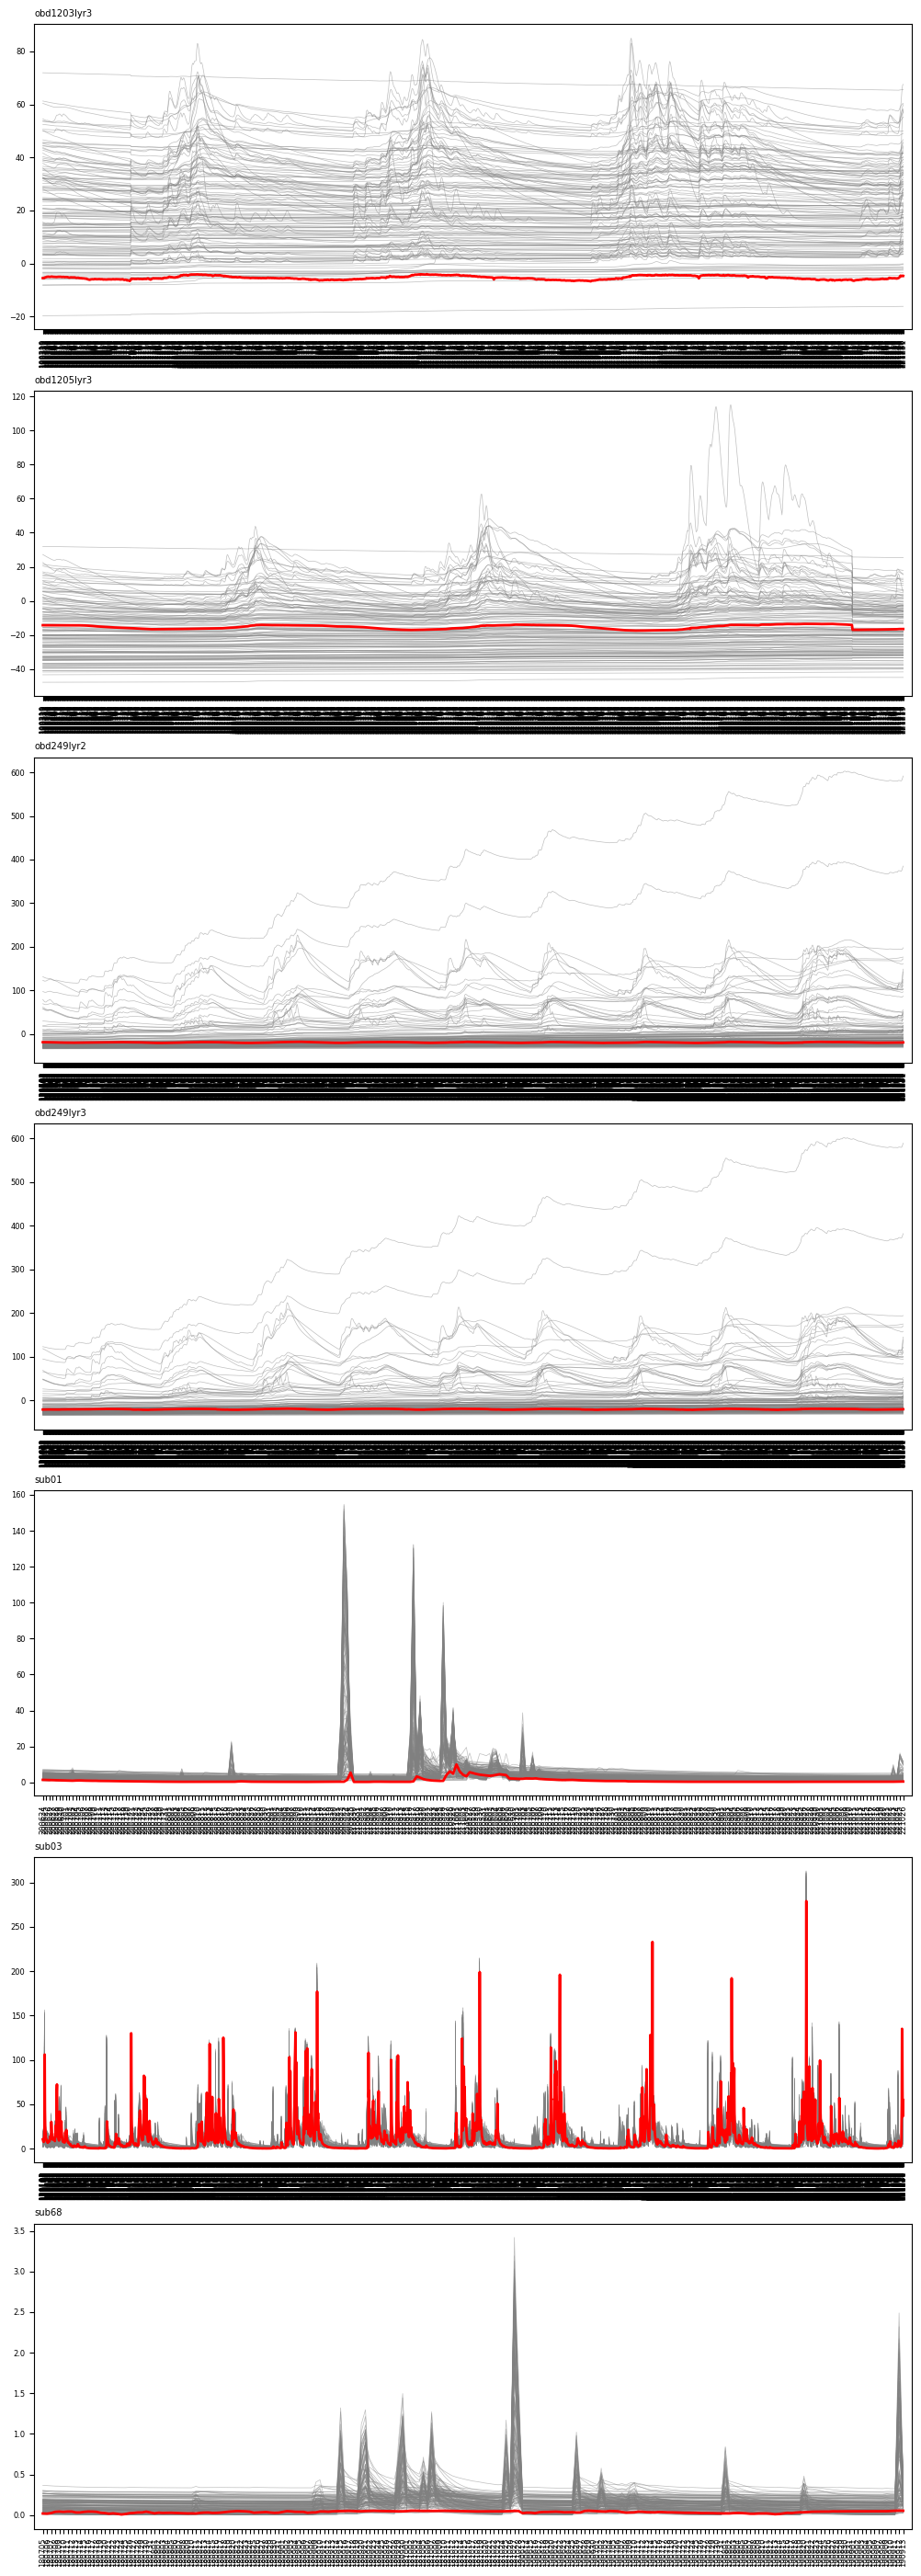

In [7]:
fig = plot_tseries_prior_ensembles(pr_oe, dot=False)

In [ ]:
# load prior simulation
pr_oe = pyemu.ObservationEnsemble.from_csv(
    pst=pst,filename=os.path.join(m_d,"koki_zon_rw_prior.0.obs.csv")
    )
# load posterior simulation
pt_oe = pyemu.ObservationEnsemble.from_csv(pst=pst,filename=os.path.join(m_d,"mb_zon_rw_ies.{0}.obs.csv".format(pst.control_data.noptmax)))


In [ ]:
# plot 1 to 1 scatter plot and residuals
pyemu.plot_utils.res_1to1(pst);

In [ ]:
# check phi values
pt_oe.phi_vector

In [ ]:
# plot progress
fig,ax = plt.subplots(1,1)
pr_oe.phi_vector.apply(np.log10).hist(ax=ax,fc="0.5",ec="none",alpha=0.5,density=False)
pt_oe.phi_vector.apply(np.log10).hist(ax=ax,fc="b",ec="none",alpha=0.5,density=False)
_ = ax.set_xlabel("$log_{10}\\phi$")

## 05.2 Prior and Posterior parameter probability

In [ ]:
prior_df = pyemu.ParameterEnsemble.from_csv(pst=pst,filename=os.path.join(m_d,"mb_zon_rw_ies.{0}.par.csv".format(0)))
post_df = pyemu.ParameterEnsemble.from_csv(pst=pst,filename=os.path.join(m_d,"mb_zon_rw_ies.{0}.par.csv".format(pst.control_data.noptmax)))

In [ ]:
df_pars = pd.read_csv(os.path.join(m_d, "mb_zon_rw_ies.par_data.csv"))
sel_pars = df_pars.loc[df_pars["partrans"]=='log']
sel_pars

In [ ]:
swatmf_viz.plot_prior_posterior_par_hist(prior_df, post_df, sel_pars)

## 05.3 Predictive Uncertainty

In [ ]:
swatmf_viz.plot_tseries_ensembles(pst, pr_oe, pt_oe, height=6, dot=True)

In [ ]:
os.getcwd()

In [ ]:
pst.parrep(parfile=os.path.join(m_d, "mb_zon_rw_ies.{0}.base.csv".format(pst.control_data.noptmax)))

In [ ]:
# updates the model input files with parameter values
pst.write_input_files(pst_path=m_d)

In [ ]:
# run the model forward run; this applies all the SWAT and MODFLOW paarameters, executes SWAT-MODFLOW 
os.chdir(m_d)
pyemu.os_utils.run('python forward_run.py')